# MNIST Handwritten Digits Classification 
from https://www.kaggle.com/competitions/classifying-handwritten-digits/data

## 1. Import Libraries


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
import os


## 2. Load and Explore Data


In [8]:
import os
# load data
train_dir = 'classifying-handwritten-digits/train'
test_dir= 'classifying-handwritten-digits/test'
train_labels_df= pd.read_csv('classifying-handwritten-digits/train_labels.csv')

#load training images
train_images =[]
train_ids =[]
for filename in sorted(os.listdir(train_dir)) :
    if filename.endswith('.png'):
        img_id =int(filename.replace('.png', ''))
        img_path= os.path.join(train_dir, filename)
        img =Image.open(img_path).convert('L')  # convert to grayscale
        img_array= np.array(img)
        train_images.append(img_array)
        train_ids.append(img_id)

X_train =np.array(train_images)
train_ids =np.array(train_ids)

# match labels with images
y_train= train_labels_df.set_index('Id').loc[train_ids]['Label'].values

# load test images
test_images = []
test_ids = []
for filename in sorted(os.listdir(test_dir)):
    if filename.endswith('.png'):
        img_id = int(filename.replace('.png', ''))
        img_path =os.path.join(test_dir, filename)
        img =Image.open(img_path).convert('L')  #convert to grayscale
        img_array= np.array(img)
        test_images.append(img_array)
        test_ids.append(img_id)

X_test =np.array(test_images)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)


Training data shape: (1000, 28, 28)
Training labels shape: (1000,)
Test data shape: (400, 28, 28)


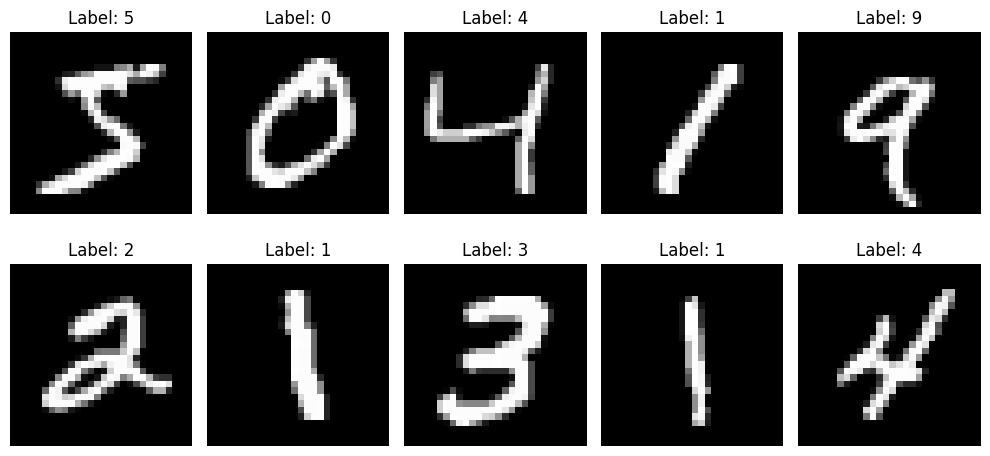

In [9]:
#examples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing


In [10]:
# normalize pixel values to [0, 1] and add channel dimension
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# + channel dimension (height, width, 1)
X_train =X_train.reshape(-1, X_train.shape[1], X_train.shape[2], 1)
X_test= X_test.reshape(-1, X_test.shape[1], X_test.shape[2], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1000, 28, 28, 1)
X_test shape: (400, 28, 28, 1)


In [11]:
# split into train and validation (90% train, 10% validation)
split =int(0.9 * len(X_train))
X_train_split = X_train[:split]
X_val_split =X_train[split:]
y_train_split = y_train[:split]
y_val_split= y_train[split:]

print("Train:",X_train_split.shape)
print("Validation:", X_val_split.shape)


Train: (900, 28, 28, 1)
Validation: (100, 28, 28, 1)


## 4. Build Simple CNN Model


In [12]:
# Simple CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()


/Users/elisedeyris/Desktop/ES_3A/Computer_Vision/computer_vision_mnist/MNIST_COMPUTER_VISION/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 5. Train Model


In [15]:
# train model

history = model.fit(
    X_train_split, y_train_split,
    batch_size=128,
    epochs=10,
    validation_data=(X_val_split, y_val_split),
    verbose=1
)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3144 - loss: 2.1091 - val_accuracy: 0.4700 - val_loss: 1.7783
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6456 - loss: 1.4335 - val_accuracy: 0.8000 - val_loss: 1.0565
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7844 - loss: 0.8075 - val_accuracy: 0.7600 - val_loss: 0.7005
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8311 - loss: 0.5517 - val_accuracy: 0.7900 - val_loss: 0.7744
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8244 - loss: 0.5284 - val_accuracy: 0.8300 - val_loss: 0.5567
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8500 - loss: 0.4642 - val_accuracy: 0.8100 - val_loss: 0.6576
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8933 - loss: 0.3598 - val_accuracy: 0.8900 - val_loss: 0.4038
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9200 - loss: 0.2928 - val_accuracy: 0.8800 - val_loss: 0.4478


In [16]:
# check accuracy
val_loss, val_acc = model.evaluate(X_val_split, y_val_split, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")


Validation Accuracy: 0.9200


In [18]:
predictions =model.predict(X_test)
test_predicted_classes = np.argmax(predictions, axis=1)

print("Predictions done!")
print(f"Number of predictions: {len(test_predicted_classes)}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predictions done!
Number of predictions: 400


## 6. Make Predictions


In [21]:
# Create submission with actual test image IDs
# Note: Kaggle expects 'Id' (capital I) and 'Label' columns
submission = pd.DataFrame({
    'Id': test_ids,
    'Label': test_predicted_classes
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved!")
print(submission.head())


Submission file saved!
     Id  Label
0  1001      7
1  1002      2
2  1003      1
3  1004      0
4  1005      4
